<a href="https://colab.research.google.com/github/nawrin1/First_Program_SM/blob/main/L9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports & Setup


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 2. Data Loading


In [29]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## 3. Data Inspection


In [30]:
missing = df.isnull().sum()

print("Missing values per column:\n")
print(missing[missing > 0])

print("\nAttack Distribution:\n")
print(df['attack_detected'].value_counts().sort_index())

print("\nClass Mapping:")
print("0 = Normal")
print("1 = Attack")

Missing values per column:

encryption_used    1966
dtype: int64

Attack Distribution:

attack_detected
0    5273
1    4264
Name: count, dtype: int64

Class Mapping:
0 = Normal
1 = Attack


## 4. Preprocessing & Train-Test Split


In [31]:
df.drop(columns=['session_id'], inplace=True)
df = pd.get_dummies(
    df,
    columns=['protocol_type', 'encryption_used', 'browser_type'],
    drop_first=True
)

df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop(columns=['attack_detected'])
y = df['attack_detected']


X_scaled = StandardScaler().fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=20
)
print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test : {X_test.shape[0]} samples")



Train: 7629 samples
Test : 1908 samples


## 5. Exploratory Data Analysis (EDA)


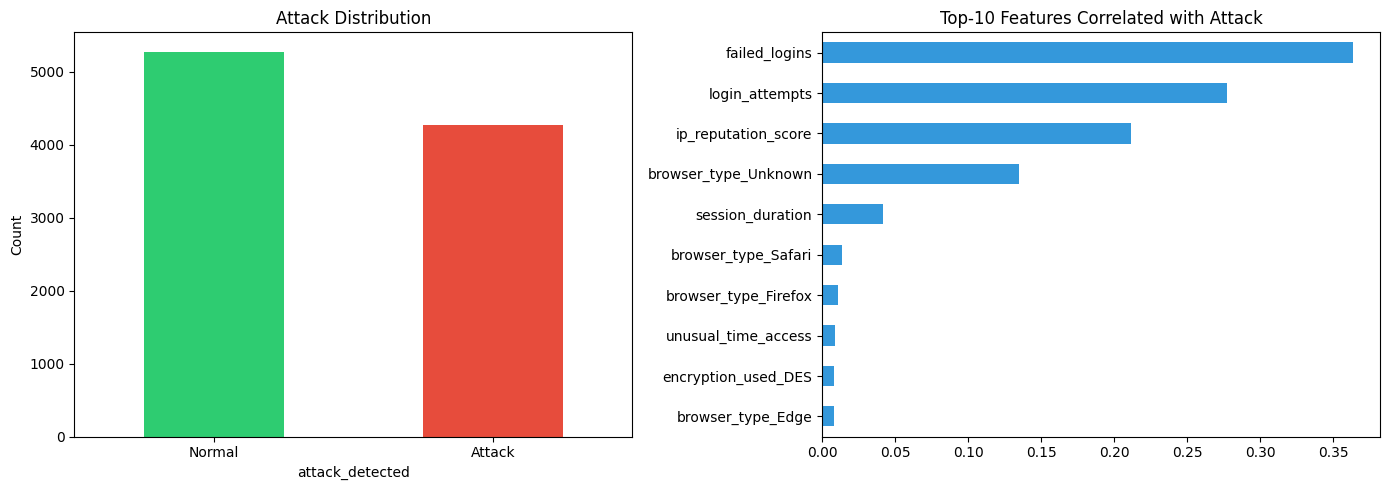

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Normal', 'Attack']


df['attack_detected'].value_counts().plot.bar(
    ax=axes[0],
    color=['#2ecc71', '#e74c3c']
)
axes[0].set_xticklabels(labels, rotation=0)
axes[0].set_title('Attack Distribution')
axes[0].set_ylabel('Count')


df.corr()['attack_detected'] \
    .drop('attack_detected') \
    .abs() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot.barh(ax=axes[1], color='#3498db')

axes[1].set_title('Top-10 Features Correlated with Attack')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Model Training & Baseline Results


In [33]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg': LogisticRegression(max_iter=1000, random_state=20)
}

results = {}
predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    yp = model.predict(X_test)

    predictions[name] = yp

    results[name] = {
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'),
        'F1-Score': f1_score(y_test, yp, average='weighted')
    }
    print(f"\n{name}")
    print(f"Accuracy  = {results[name]['Accuracy']:.4f}")
    print(f"Precision = {results[name]['Precision']:.4f}")
    print(f"Recall    = {results[name]['Recall']:.4f}")
    print(f"F1-Score  = {results[name]['F1-Score']:.4f}")


Decision Tree
Accuracy  = 0.8077
Precision = 0.8137
Recall    = 0.8077
F1-Score  = 0.8084

KNN (k=5)
Accuracy  = 0.8092
Precision = 0.8152
Recall    = 0.8092
F1-Score  = 0.8053

Logistic Reg
Accuracy  = 0.7442
Precision = 0.7431
Recall    = 0.7442
F1-Score  = 0.7431


## 7. Decision Tree — Depth Tuning



Decision Tree Depth Results:

           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8852     0.9046  0.8852    0.8818
5            0.9093     0.9219  0.9093    0.9074
10           0.9015     0.9096  0.9015    0.8999
15           0.8920     0.8970  0.8920    0.8907
20           0.8784     0.8800  0.8784    0.8775
None         0.8077     0.8137  0.8077    0.8084


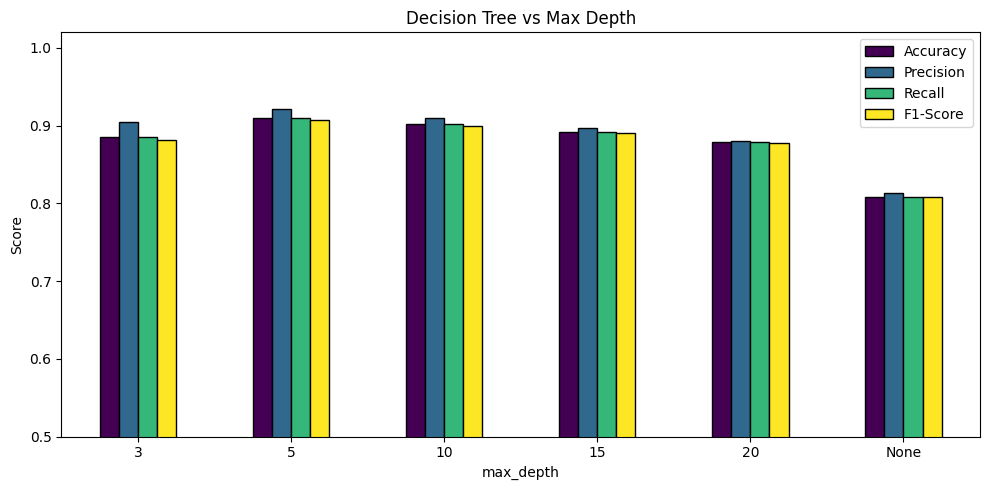

In [34]:
dt_results = []

for d in [3, 5, 10, 15, 20, None]:

    dt = DecisionTreeClassifier(
        max_depth=d,
        random_state=20
    )

    dt.fit(X_train, y_train)

    yp = dt.predict(X_test)
    dt_results.append({
        'max_depth': str(d),
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'),
        'F1-Score': f1_score(y_test, yp, average='weighted')
    })

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print("\nDecision Tree Depth Results:\n")
print(dt_df.round(4))

# Plot Results
dt_df.plot(
    kind='bar',
    figsize=(10, 5),
    colormap='viridis',
    edgecolor='black'
)
plt.title('Decision Tree vs Max Depth')
plt.ylabel('Score')
plt.ylim(0.5, 1.02)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Classification Reports


In [35]:
target_names = ['Normal', 'Attack']

for name, yp in predictions.items():

    print(f"\n{'='*55}")
    print(name)
    print(f"{'='*55}")
    print(
        classification_report(
            y_test,
            yp,
            target_names=target_names,
            digits=4
        )
    )



Decision Tree
              precision    recall  f1-score   support

      Normal     0.8637    0.7827    0.8212      1077
      Attack     0.7489    0.8400    0.7918       831

    accuracy                         0.8077      1908
   macro avg     0.8063    0.8113    0.8065      1908
weighted avg     0.8137    0.8077    0.8084      1908


KNN (k=5)
              precision    recall  f1-score   support

      Normal     0.7859    0.9099    0.8434      1077
      Attack     0.8533    0.6787    0.7560       831

    accuracy                         0.8092      1908
   macro avg     0.8196    0.7943    0.7997      1908
weighted avg     0.8152    0.8092    0.8053      1908


Logistic Reg
              precision    recall  f1-score   support

      Normal     0.7604    0.7985    0.7790      1077
      Attack     0.7207    0.6739    0.6965       831

    accuracy                         0.7442      1908
   macro avg     0.7406    0.7362    0.7378      1908
weighted avg     0.7431    0.7442 

## 9. Confusion Matrices


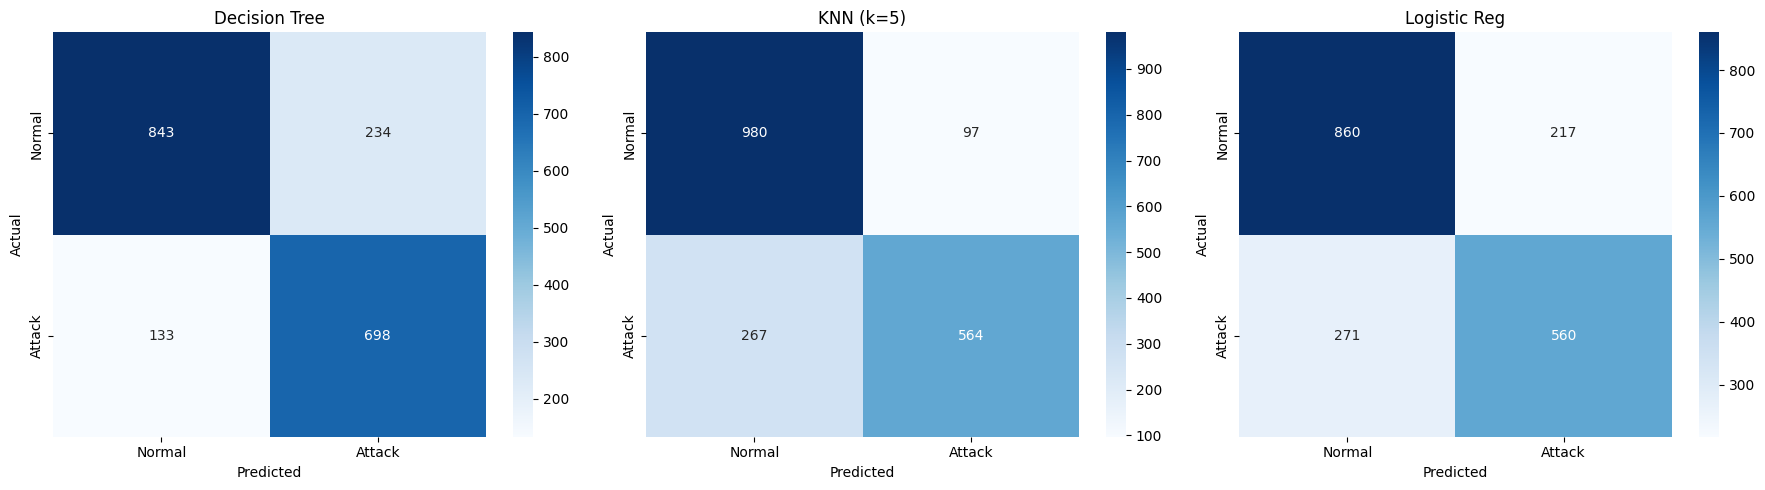

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, yp) in zip(axes, predictions.items()):

    sns.heatmap(
        confusion_matrix(y_test, yp),
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=target_names,
        yticklabels=target_names
    )
    ax.set_title(name)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 10. Model Comparison


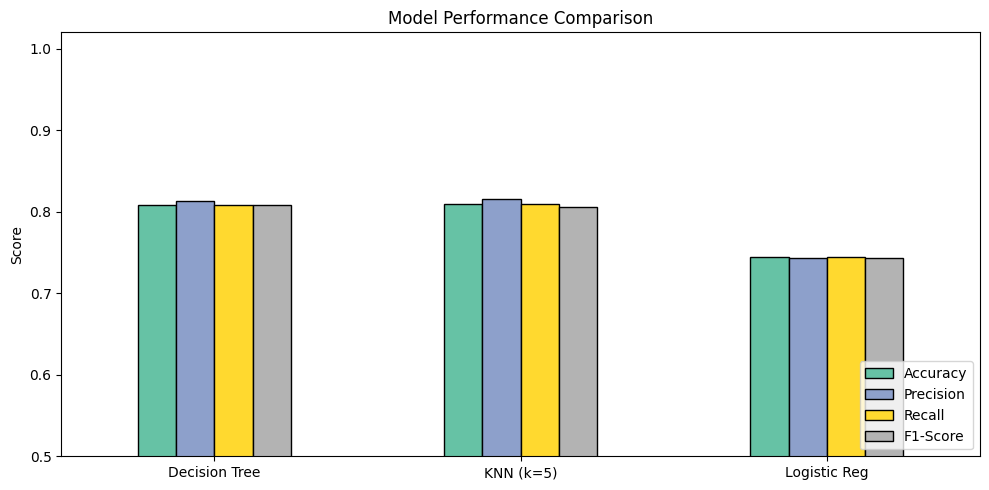


Summary:

               Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8077     0.8137  0.8077    0.8084
KNN (k=5)        0.8092     0.8152  0.8092    0.8053
Logistic Reg     0.7442     0.7431  0.7442    0.7431


In [37]:
res_df = pd.DataFrame(results).T

res_df.plot(
    kind='bar',
    figsize=(10, 5),
    colormap='Set2',
    edgecolor='black'
)

plt.title('Model Performance Comparison')

plt.ylabel('Score')

plt.ylim(0.5, 1.02)
plt.xticks(rotation=0)

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\nSummary:\n")
print(res_df.round(4))

## 11. Assignment

**Dataset:** [Cybersecurity Intrusion Detection Dataset](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset)

Upload the dataset to your Google Drive under `datasets/` and complete the following tasks using the **same workflow** as this notebook.

| Task | What to do |
|------|------------|
| **1. Load & Inspect** | Load CSV, print shape, missing values, and class distribution |
| **2. Preprocess** | Drop irrelevant columns, fill missing values with median, scale features, split 80/20 |
| **3. EDA** | Bar chart of class distribution + top-10 feature correlations |
| **4. Train Models** | Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1 |
| **5. Depth Tuning** | Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart |
| **6. Evaluate** | Classification reports + 1×3 confusion matrix grid + model comparison bar chart |

**Submit:** Single `.ipynb` with all cells executed and clean output.